# Excess deaths due to COVID-19

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pymc_extras.prior import Prior

import causalpy as cp

In [3]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
seed = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

In [4]:
df = (
    cp.load_data("covid")
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .set_index("date")
)

treatment_time = pd.to_datetime("2020-01-01")
df.head()

,temp,deaths,year,month,t,pre
date,,,,,,
2006-01-01,3.8,49124,2006,1,0,True
2006-02-01,3.4,42664,2006,2,1,True
2006-03-01,3.9,49207,2006,3,2,True
2006-04-01,7.4,40645,2006,4,3,True
2006-05-01,10.7,42425,2006,5,4,True


The columns are:

* `date` + `year`: self explanatory
* `month`: month, numerically encoded. Needs to be treated as a categorical variable
* `temp`: average UK temperature (Celsius)
* `t`: time
* `pre`: boolean flag indicating pre or post intervention

## A linear-trend baseline

Let's begin with a simple model that assumes a straight-line trend in `t`, along with monthly fixed effects, and an adjustment for temperature. Since our outcome variable is standardized, we'll place unit normal priors on our regression coefficients and a half normal on the standard deviation.


:::{note}
In this example we are going to standardize the data. So we have to be careful in how we interpret the inferred regression coefficients, and the posterior predictions will be in this standardized space.
:::  

:::{note}
The `random_seed` keyword argument for the PyMC sampler is not necessary. We use it here so that the results are reproducible.
:::

In [5]:
model = cp.pymc_models.LinearRegression(
    sample_kwargs={"random_seed": seed},
    priors={
        "beta": Prior("Normal", mu=0, sigma=1, dims=["treated_units", "coeffs"]),
        "y_hat": Prior(
            "Normal",
            sigma=Prior("HalfNormal", sigma=0.5, dims=["treated_units"]),
            dims=["obs_ind", "treated_units"],
        ),
    },
)

In [6]:
result_linear = cp.InterruptedTimeSeries(
    df,
    treatment_time,
    formula="standardize(deaths) ~ 0 + standardize(t) + C(month) + standardize(temp)",
    model=model,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]
                                                                                
                               Step       Grad                                  
  Progress   Draw   Diverge…   size       evals      Speed   Elapsed   Remain…  
 ────────────────────────────────────────────────────────────────────────────── 
                                                                                
                             Step      Grad                                     
  Progre…   Draw   Diverg…   size      evals      Speed     Elapsed   Remaini…  
 ────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━   0      0         0.000     0          0.00      0:00:00   -:--:--   
                                                  draws/s                       
                                                                            

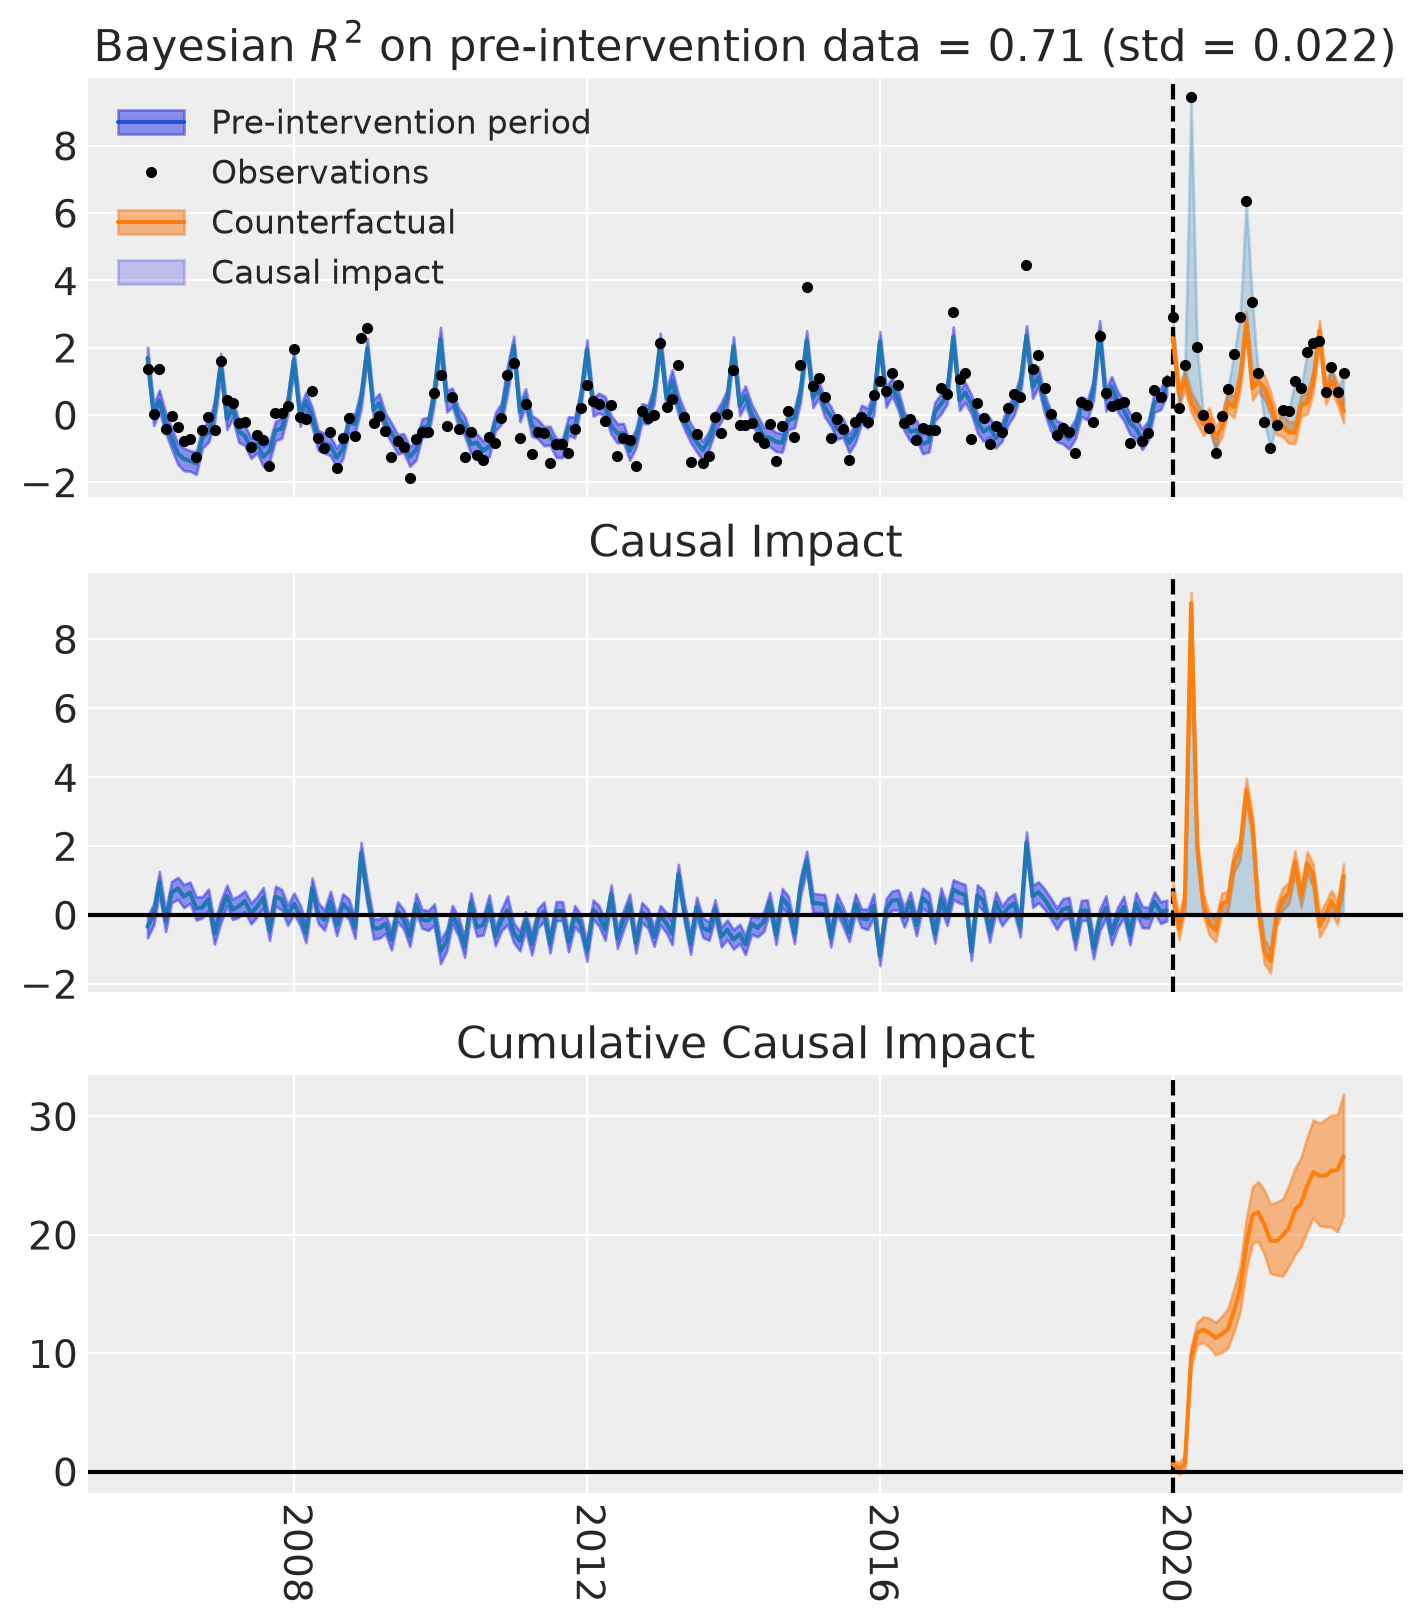

In [7]:
fig, ax = result_linear.plot()

In [8]:
result_linear.summary()

==================================Pre-Post Fit==================================
Formula: standardize(deaths) ~ 0 + standardize(t) + C(month) + standardize(temp)
Model coefficients:
  C(month)[1]        1.5, 94% HDI [1.1, 1.9]
  C(month)[2]        -0.25, 94% HDI [-0.68, 0.13]
  C(month)[3]        0.22, 94% HDI [-0.13, 0.56]
  C(month)[4]        -0.045, 94% HDI [-0.31, 0.25]
  C(month)[5]        -0.13, 94% HDI [-0.41, 0.17]
  C(month)[6]        -0.16, 94% HDI [-0.54, 0.2]
  C(month)[7]        0.046, 94% HDI [-0.42, 0.49]
  C(month)[8]        -0.35, 94% HDI [-0.79, 0.081]
  C(month)[9]        -0.39, 94% HDI [-0.74, -0.034]
  C(month)[10]       -0.042, 94% HDI [-0.31, 0.22]
  C(month)[11]       -0.38, 94% HDI [-0.7, -0.062]
  C(month)[12]       0.019, 94% HDI [-0.37, 0.42]
  standardize(t)     0.23, 94% HDI [0.15, 0.31]
  standardize(temp)  -0.49, 94% HDI [-0.74, -0.24]


## Adding flexibility
This model doesn't look too bad, but with a pre-treatment period Bayesian $R^2$ of 0.71, we have some room for improvement. One thing we could try is to relax our assumption that the trend is globally linear. In doing so, we might improve pretreatment fit and partially deconfound our other coefficients. To this end, let's try to swap the linear model for `t` for a spline. We can use `cr()` from Patsy to fit a cubic regression spline in the cardinal parameterization. `cr()` takes an argument for the number of degrees of freedom for the fit. For `df=k` you get `k` basis columns, and then coefficient `j` is simply the value of the fitted curve at knot `j`.

CausalPy makes fitting this model easy enough, so let's try it! We'll swap in `cr(t, df=6)` and keep our uninformative normal priors on the coefficients.

In [9]:
ridge_spline = cp.pymc_models.LinearRegression(
    sample_kwargs={"random_seed": seed},
    priors={
        "beta": Prior("Normal", mu=0, sigma=50, dims=["treated_units", "coeffs"]),
        "y_hat": Prior(
            "Normal",
            sigma=Prior("HalfNormal", sigma=0.5, dims=["treated_units"]),
            dims=["obs_ind", "treated_units"],
        ),
    },
)

result_ridge = cp.InterruptedTimeSeries(
    df,
    treatment_time,
    formula="standardize(deaths) ~ 0 + cr(t, df=6) + C(month) + standardize(temp)",
    model=ridge_spline,
)

print(f"pre-intervention R2 = {result_ridge.score['unit_0_r2']:.3f}")
az.summary(result_ridge.model.idata, var_names=["beta"]).sort_values("ess_bulk").head(5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]
                                                                                
                               Step       Grad                                  
  Progress   Draw   Diverge…   size       evals      Speed   Elapsed   Remain…  
 ────────────────────────────────────────────────────────────────────────────── 
                                                                                
                             Step      Grad                                     
  Progre…   Draw   Diverg…   size      evals      Speed     Elapsed   Remaini…  
 ────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━   0      0         0.000     0          0.00      0:00:00   -:--:--   
                                                  draws/s                       
                                                                            

pre-intervention R2 = 0.746


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[unit_0, C(month)[10]]",1.025,10.688,-19.517,20.509,0.842,0.586,157.0,178.0,1.03
"beta[unit_0, C(month)[5]]",0.946,10.689,-19.762,20.365,0.842,0.585,157.0,177.0,1.03
"beta[unit_0, C(month)[6]]",0.989,10.691,-19.363,20.621,0.844,0.585,157.0,179.0,1.03
"beta[unit_0, C(month)[7]]",1.258,10.691,-19.109,20.911,0.845,0.585,157.0,177.0,1.03
"beta[unit_0, C(month)[8]]",0.842,10.690,-19.383,20.541,0.844,0.585,157.0,173.0,1.03


The fit improved, but the sampler is unhappy. For at least some of our parameters, the chains have not converged and our effective sample size is weak. Notice also that the estimated standard deviations have almost exactly the same value. Together, these are good hints for a flat ridge in the posterior geometry.

array([[<Axes: ylabel='beta\ncr(t, df=6)[0]'>, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='beta\ncr(t, df=6)[1]'>, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='beta\ncr(t, df=6)[2]'>, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='beta\ncr(t, df=6)[0]', ylabel='beta\ncr(t, df=6)[3]'>,
        <Axes: xlabel='beta\ncr(t, df=6)[1]'>,
        <Axes: xlabel='beta\ncr(t, df=6)[2]'>,
        <Axes: xlabel='beta\ncr(t, df=6)[3]'>]], dtype=object)

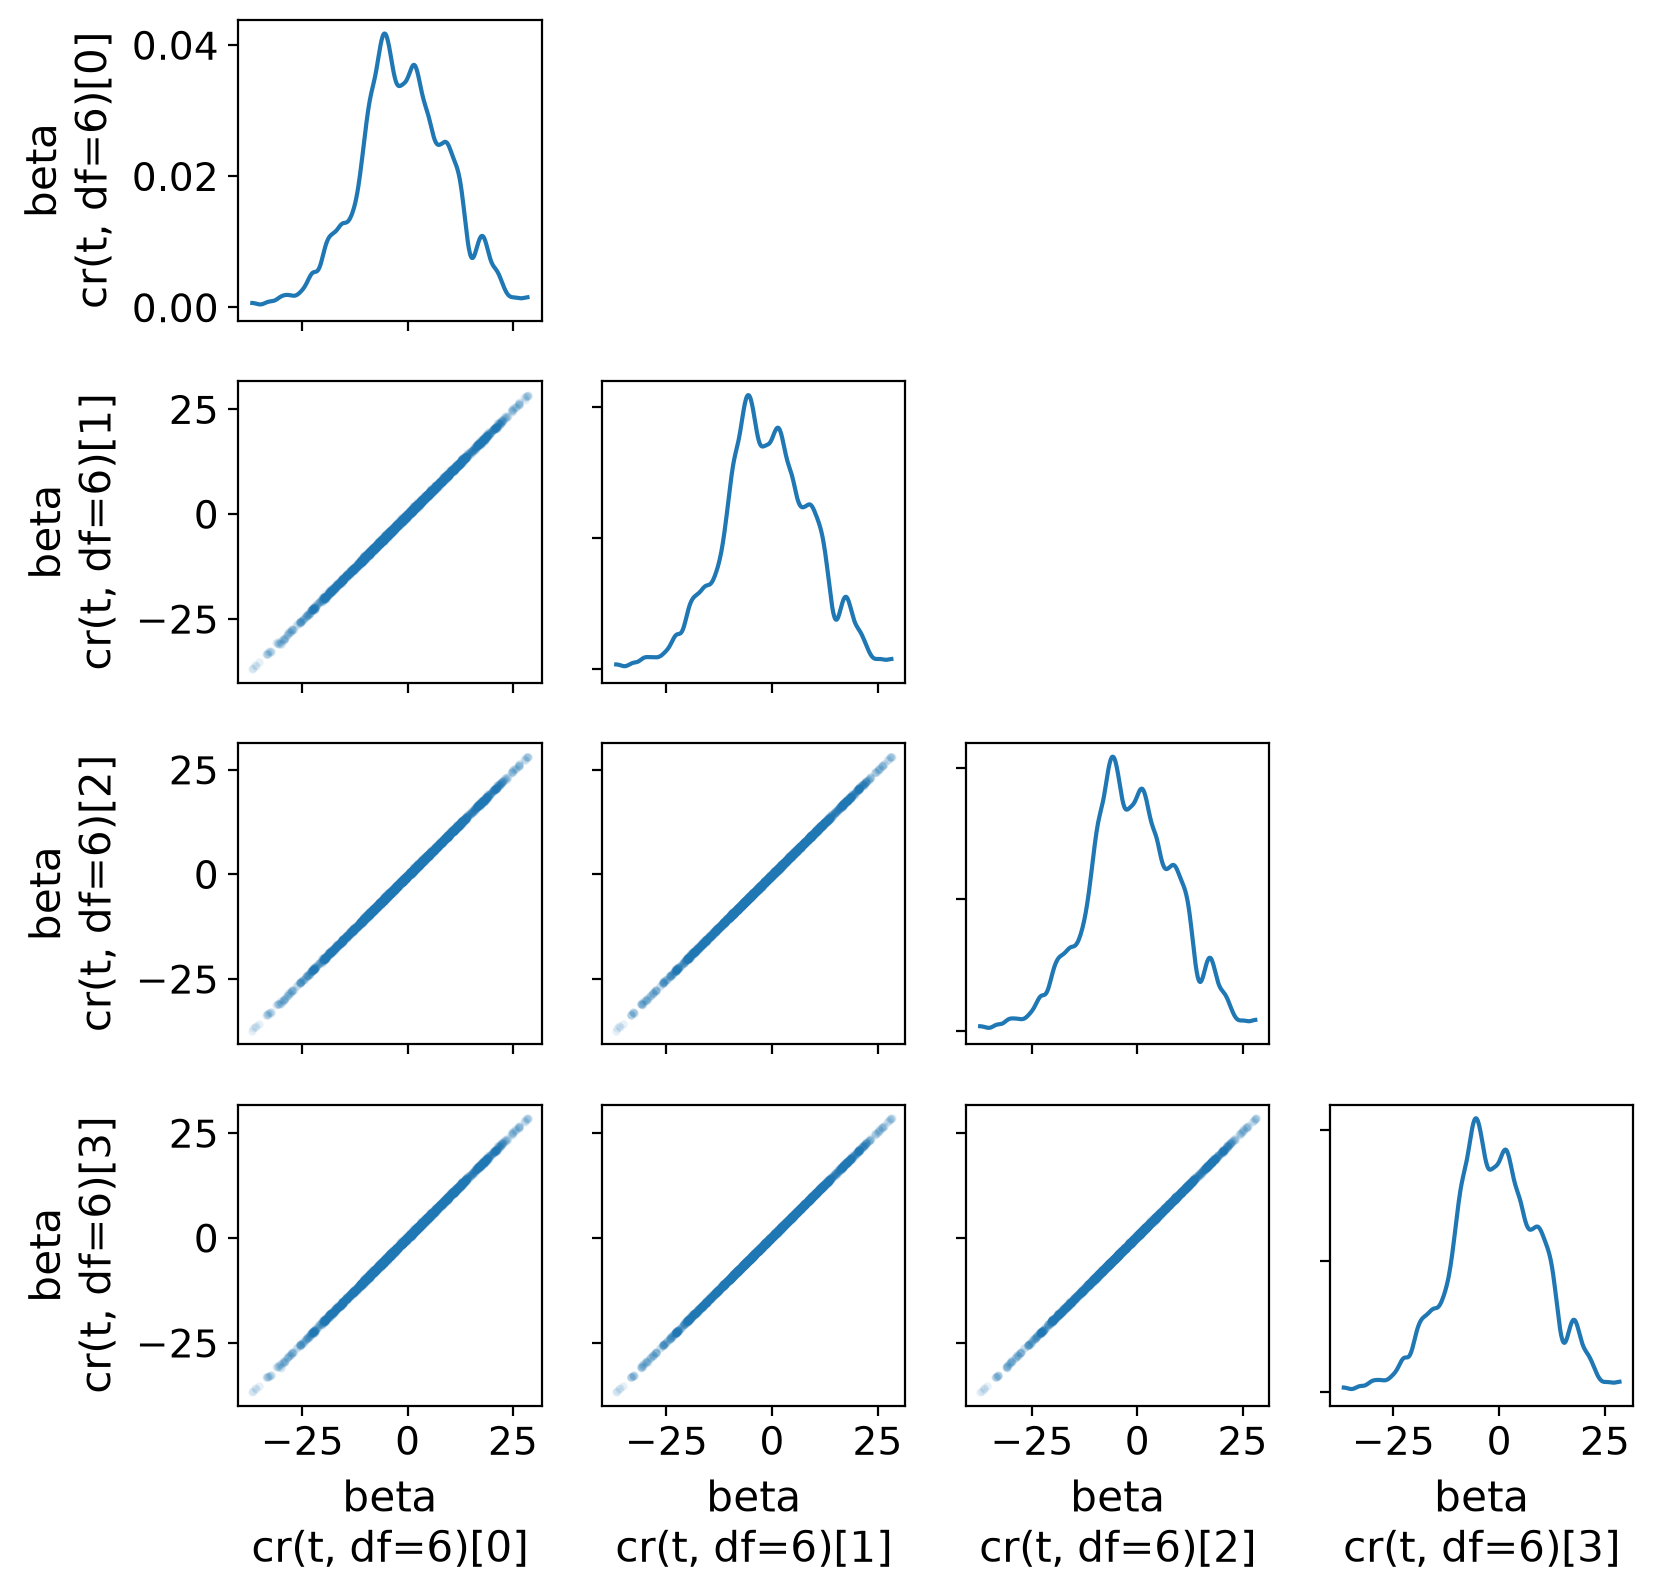

In [10]:
# Zoom in on a few of the spline coefficients to inspect the posterior geometry.
idata = result_ridge.model.idata
spline_coeffs = [
    c for c in idata.posterior["beta"].coords["coeffs"].values if c.startswith("cr(t")
]

az.plot_pair(
    idata,
    group="posterior",
    var_names=["beta"],
    coords={"treated_units": "unit_0", "coeffs": spline_coeffs[:4]},
    kind="scatter",
    divergences=True,
    marginals=True,
    scatter_kwargs={"alpha": 0.1},
    figsize=(9, 9),
)

In this case, the cause is a rank deficiency in the design matrix. Since `cr()` is a cardinal basis, its rows sum to one, which means a simple constant function lies in its span. With `0 +` in the formula, patsy also gives `C(month)` all twelve levels rather than eleven, so the month variables also span the constant function. In effect, we've accidentally represented the intercept twice, so only the sum of the two levels is identified by the data.

In [11]:
X = result_ridge.pre_design["X"]
spline_cols = [c for c in X.coeffs.values if c.startswith("cr(")]
month_cols = [c for c in X.coeffs.values if c.startswith("C(month)")]

print(f"design matrix rank {np.linalg.matrix_rank(X.values)} of {X.shape[1]} columns")
print(f"cr() row sums: {X.sel(coeffs=spline_cols).sum('coeffs').values.min():.6f}")

design matrix rank 18 of 19 columns
cr() row sums: 1.000000


## Bayesian P-spline with a second-order random walk prior
Okay, so we need to address this redundant intercept. While we're at it, let's improve the prior model for our spline too! Rather than treat each spline coefficient as exchangeable, let's give them more informative, regularizing priors. A P-spline does this by penalising the second differences of neighboring coefficients. One Bayesian implementation of this is the second-order random walk (RW2) prior!
$$
\beta_j - 2\beta_{j-1} + \beta_{j-2} \sim \operatorname{Normal}(0,\sigma^2_{\text{smooth}})
$$

Because `cr()` coefficients are the curve's values at the knots, this prior model implies that the trend in `t` has little curvature, if any, with $\sigma_{\text{smooth}}$, learned from the data, controlling how much. P-splines let us be really generous with the `df` and let this penalty do the heavy lifting.

### The null space
Writing the second differences as $D\beta$, the prior is $\beta \sim \mathrm{Normal}(0, \sigma_{\text{smooth}}^2 P^{-})$ with $P = D^\top D$. Here, $P$ is rank deficient by two because adding a constant or a straight line to $\beta$ doesn't change the second difference. We'll drop the constant, since we know we need to eliminate this redundancy, and let `C(month)` carry that level. We can keep the linear direction though, as a learned parameter, `spline_slope`. This lets our model's counterfactual extrapolate with a reasonable slope once we run past the last knot, adding a bit more flexibility.

Everything else we'll parameterize non-centered through the whitened penalty $Z = V_{+} \Lambda_{+}^{-1/2}$, built from the positive part of the eigendecomposition of $P$. Then $\operatorname{Cov}(Zz) = P^{-}$ exactly, the columns of $Z$ are orthogonal to both null directions, and the sampler sees standard normal variables instead of a funnel. Finally, normalizing the eigenvalues by their geometric mean keeps $\sigma_{\text{smooth}}$ meaning the same thing even if we vary `df` (which will come in handy later!).

In [12]:
def rw2_basis(n_knots: int) -> np.ndarray:
    """Whitened RW2 penalty, with constant and linear null directions removed.

    Returns an ``(n_knots, n_knots - 2)`` matrix ``Z`` such that ``Z @ z`` with
    ``z ~ Normal(0, 1)`` has covariance equal to the pseudo-inverse of the second
    difference penalty, rescaled so that the geometric mean of the marginal
    variances is one. This rescaling lets the smoothing standard deviation mean
    the same thing regardless of the knot count.
    """
    D = np.diff(np.eye(n_knots), n=2, axis=0)
    eigenvalues, eigenvectors = np.linalg.eigh(D.T @ D)
    keep = eigenvalues > 1e-8 * eigenvalues.max()
    lam, V = eigenvalues[keep], eigenvectors[:, keep]
    Z = V / np.sqrt(lam)
    marginal_variance = (Z**2).sum(axis=1)
    return Z / np.sqrt(np.exp(np.mean(np.log(marginal_variance))))

Thankfully, pymc-extras lets us specify this prior, with a little help from the `VariableFactory` protocol. Any object with a `dims` attribute and a `create_variable` method can be swapped in wherever `Prior` can. CausalPy's `LinearRegression` builds coefficients via `self.priors["beta"].create_variables("beta")`, so we can pass in our own custom prior here!

The variable factory reads the column names from the model's `coeffs` coordinate, splits them into spline and non-spline blocks, and reassembles them into a `beta` container for CausalPy.

In [13]:
class RW2SplinePrior:
    """RW2 (P-spline) prior on the spline columns, Normal on everything else.

    Implements the ``VariableFactory`` protocol from ``pymc_extras.prior``, so it can
    be passed as the ``beta`` prior of any CausalPy model that builds its coefficients
    with ``create_variable``. Columns whose name starts with ``spline_prefix`` get the
    smoothness prior; the rest keep an ordinary normal.
    """

    def __init__(
        self,
        spline_prefix="cr(",
        smoothing_sigma=0.5,
        slope_sigma=2.0,
        beta_sigma=1.0,
        dims=("treated_units", "coeffs"),
    ):
        self.spline_prefix = spline_prefix
        self.smoothing_sigma = smoothing_sigma
        self.slope_sigma = slope_sigma
        self.beta_sigma = beta_sigma
        self.dims = tuple(dims)

    def create_variable(self, name, xdist=False):
        model = pm.modelcontext(None)
        labels = list(model.coords["coeffs"])
        spline_idx = np.array(
            [
                i
                for i, label in enumerate(labels)
                if label.startswith(self.spline_prefix)
            ]
        )
        if spline_idx.size < 4:
            raise ValueError(
                f"Need at least 4 columns starting with {self.spline_prefix!r}, "
                f"found {spline_idx.size} in {labels}."
            )
        other_idx = np.array(
            [i for i in range(len(labels)) if i not in set(spline_idx.tolist())]
        )

        n_knots = len(spline_idx)
        Z = rw2_basis(n_knots)
        ramp = np.arange(n_knots) - (n_knots - 1) / 2
        ramp = ramp / np.linalg.norm(ramp)  # the trend

        model.add_coords(
            {
                "spline_coeffs": [labels[i] for i in spline_idx],
                "other_coeffs": [labels[i] for i in other_idx],
                "wiggle": np.arange(n_knots - 2),
            }
        )

        # RW2 block gets the smoothness scale, whitened wiggliness, explicit slope
        sigma_smooth = pm.HalfNormal(
            "sigma_smooth", self.smoothing_sigma, dims="treated_units"
        )
        z = pm.Normal("z_spline", 0.0, 1.0, dims=["treated_units", "wiggle"])
        slope = pm.Normal("spline_slope", 0.0, self.slope_sigma, dims="treated_units")
        beta_spline = pm.Deterministic(
            "beta_spline",
            sigma_smooth[:, None] * pt.dot(z, Z.T) + slope[:, None] * ramp[None, :],
            dims=["treated_units", "spline_coeffs"],
        )

        # everything else keeps an ordinary normal prior.
        beta_other = pm.Normal(
            "beta_other", 0.0, self.beta_sigma, dims=["treated_units", "other_coeffs"]
        )

        # packing these together for the `beta` container CausalPy needs
        beta = pt.zeros((len(model.coords["treated_units"]), len(labels)))
        beta = pt.set_subtensor(beta[:, spline_idx], beta_spline)
        beta = pt.set_subtensor(beta[:, other_idx], beta_other)
        return pm.Deterministic(name, beta, dims=list(self.dims))


def pspline_model(**sample_kwargs):
    return cp.pymc_models.LinearRegression(
        sample_kwargs={"random_seed": seed, "target_accept": 0.95, **sample_kwargs},
        priors={
            "beta": RW2SplinePrior(),
            "y_hat": Prior(
                "Normal",
                sigma=Prior("HalfNormal", sigma=0.5, dims=["treated_units"]),
                dims=["obs_ind", "treated_units"],
            ),
        },
    )

Because the penalty determines the smoothness, we can afford far more knots than the six we tried earlier. Let's double it to 12.

In [14]:
formula = "standardize(deaths) ~ 0 + cr(t, df=12) + C(month) + standardize(temp)"

result = cp.InterruptedTimeSeries(
    df,
    treatment_time,
    formula=formula,
    model=pspline_model(),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_smooth, z_spline, spline_slope, beta_other, y_hat_sigma]
                                                                                
                               Step       Grad                                  
  Progress   Draw   Diverge…   size       evals      Speed   Elapsed   Remain…  
 ────────────────────────────────────────────────────────────────────────────── 
                                                                                
                             Step      Grad                                     
  Progre…   Draw   Diverg…   size      evals      Speed     Elapsed   Remaini…  
 ────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━   0      0         0.000     0          0.00      0:00:00   -:--:--   
                                                  draws/s                       
                                

In [15]:
def diagnostics(name, experiment, var_names):
    idata = experiment.model.idata
    summary = az.summary(idata, var_names=var_names)
    return {
        "model": name,
        "max r_hat": summary["r_hat"].max(),
        "min ess_bulk": summary["ess_bulk"].min(),
        "divergences": int(idata.sample_stats["diverging"].sum()),
        "pre-period R²": experiment.score["unit_0_r2"],
    }


pd.DataFrame(
    [
        diagnostics("linear trend", result_linear, ["beta", "y_hat_sigma"]),
        diagnostics("cr(df=6), ridge prior", result_ridge, ["beta", "y_hat_sigma"]),
        diagnostics(
            "cr(df=12), RW2 prior",
            result,
            ["sigma_smooth", "z_spline", "spline_slope", "beta_other", "y_hat_sigma"],
        ),
    ]
).set_index("model").round(3)

,max r_hat,min ess_bulk,divergences,pre-period R²
model,,,,
linear trend,1.01,708.0,0,0.709
"cr(df=6), ridge prior",1.03,157.0,0,0.746
"cr(df=12), RW2 prior",1.01,906.0,0,0.742


This looks great! $\hat{R}$ is back near 1 with a healthy bulk ESS, while the pre-treatment fit maintains the improvement the spline provides. In this notebook, we've worked through a simple example of how CausalPy's integration with the larger PyMC ecosystem allows for rapid development of counterfactual models.

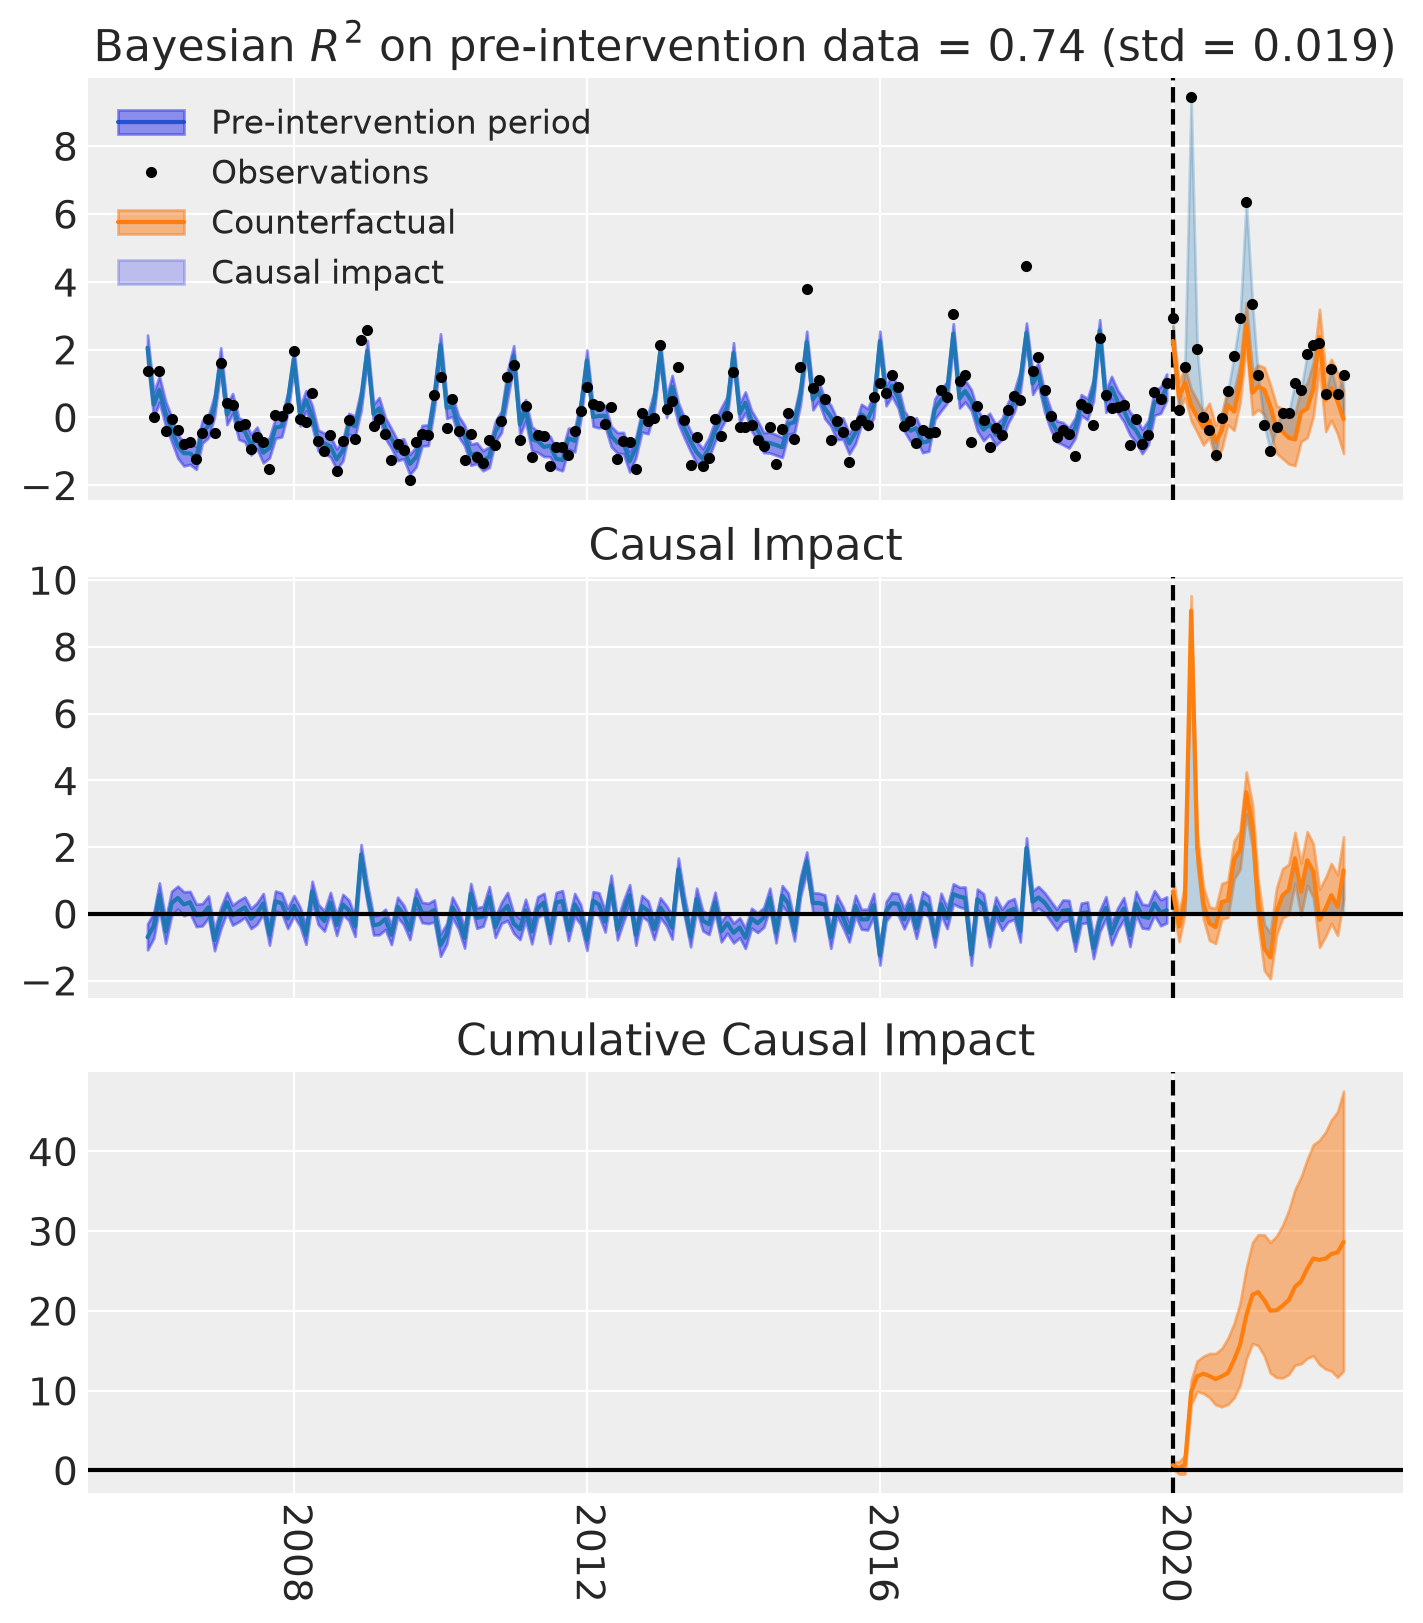

In [16]:
fig, ax = result.plot()

It's instructive to look at the trend component on its own since the post-intervention period of an ITS regression is our counterfactual model. If we multiply the `cr()` columns of the design matrices by the `beta_spline` posterior, we get back the smooth trend over both periods. 

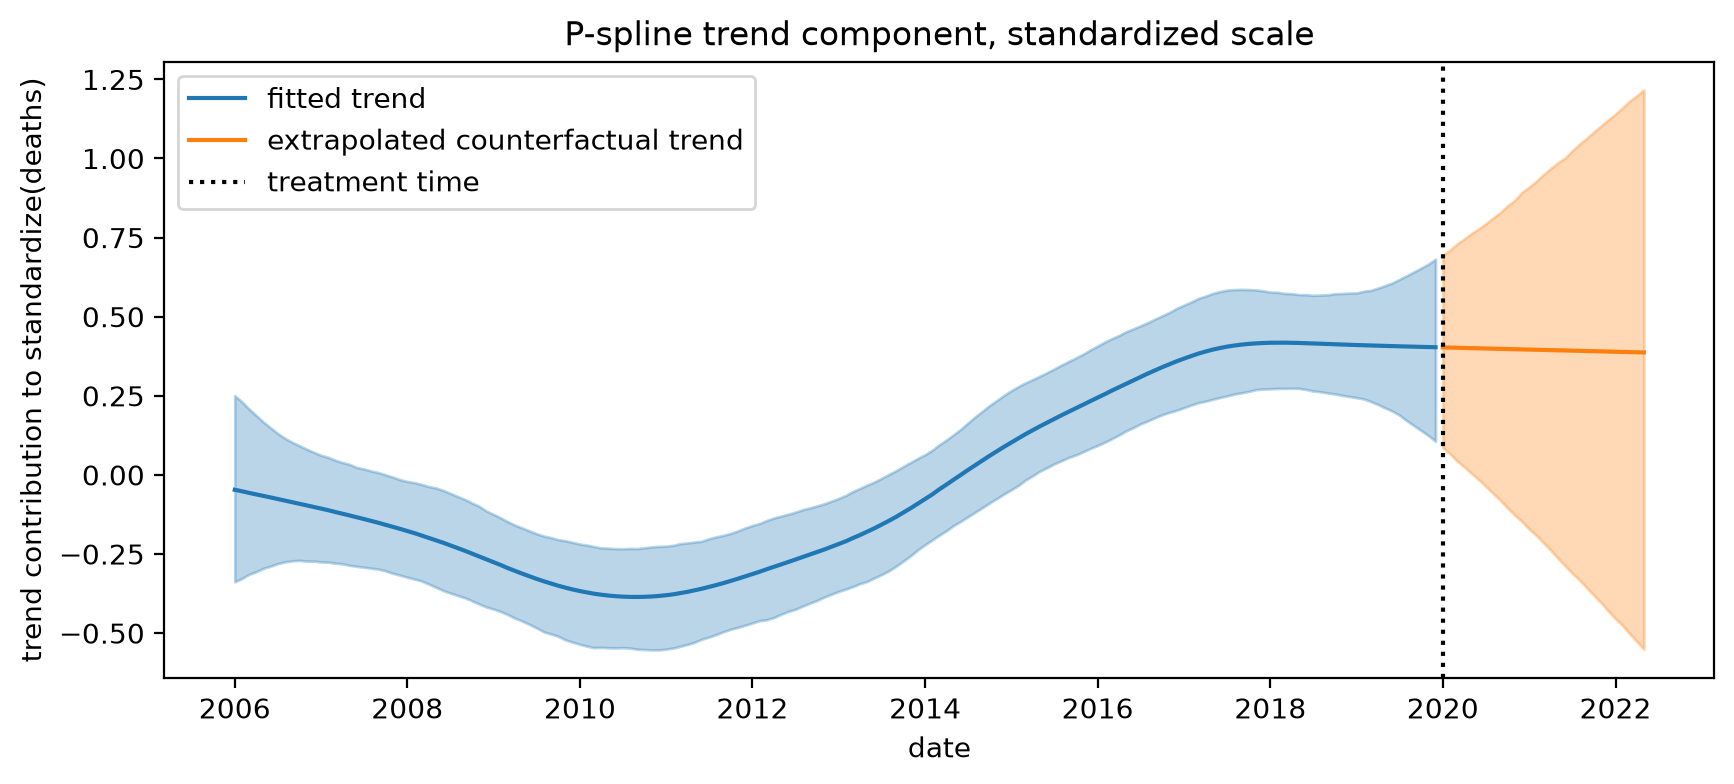

In [17]:
def trend_draws(experiment, design):
    """Posterior draws of the smooth trend component for one design matrix."""
    X = design["X"]
    cols = [c for c in X.coeffs.values if c.startswith("cr(")]
    beta_spline = (
        experiment.model.idata.posterior["beta_spline"]
        .isel(treated_units=0)
        .rename({"spline_coeffs": "coeffs"})
    )
    return (X.sel(coeffs=cols) * beta_spline).sum("coeffs")


trend_pre = trend_draws(result, result.pre_design)
trend_post = trend_draws(result, result.post_design)

fig, ax = plt.subplots(figsize=(10, 4))
for trend, colour, label in [
    (trend_pre, "C0", "fitted trend"),
    (trend_post, "C1", "extrapolated counterfactual trend"),
]:
    stacked = trend.stack(sample=("chain", "draw"))
    lower, upper = np.quantile(stacked.values, [0.03, 0.97], axis=-1)
    ax.fill_between(trend.obs_ind.values, lower, upper, color=colour, alpha=0.3)
    ax.plot(
        trend.obs_ind.values, stacked.mean("sample").values, color=colour, label=label
    )

ax.axvline(treatment_time, color="k", ls=":", label="treatment time")
ax.set(
    title="P-spline trend component, standardized scale",
    xlabel="date",
    ylabel="trend contribution to standardize(deaths)",
)
ax.legend()
plt.show()

Note that the counterfactual trend is linear throughout the post-treatment period. While `cr()` is a natural spline (so it extrapolates linearly past the last knot), the RW2 prior's linear direction (`spline_slope`) learns that slope. The spline columns earn their place not by bending the counterfactual (they can't!) but by (1) letting the local slope be governed by the trend near the intervention rather than a global average, and (2) removing pre-treatment misspecification that would otherwise leak into the seasonal terms and the residual scale.

## Does the knot count matter?
This is really the payoff of the penalty. With the ridge prior, the fit depends heavily on `df`, because `df` is the only knob controlling how wiggly the curve can get. With the RW2 prior, $\sigma_{\text{smooth}}$ takes over that job, so `df` just has to be big enough to resolve the features in the data. Past that point, adding knots buys us nothing but sampling time.

Let's sweep from 6 knots up to 30. Thirty knots is roughly one per five months of pre-treatment data, which the ridge prior would probably overfit. Under the penalty, the fitted trend is hard to tell apart from the 6-knot one.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_smooth, z_spline, spline_slope, beta_other, y_hat_sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [beta_other, sigma_smooth, spline_slope, y_hat, y_hat_sigma, z_spline]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_smooth, z_spline, spline_slope, beta_other, y_hat_sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [beta_other, sigma_smooth, spline_slope, y_hat, y_hat_sigma, z_spline]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_smooth, z_spline, spline_slope, beta_other, y_hat_sigma]
Sampling 4 cha

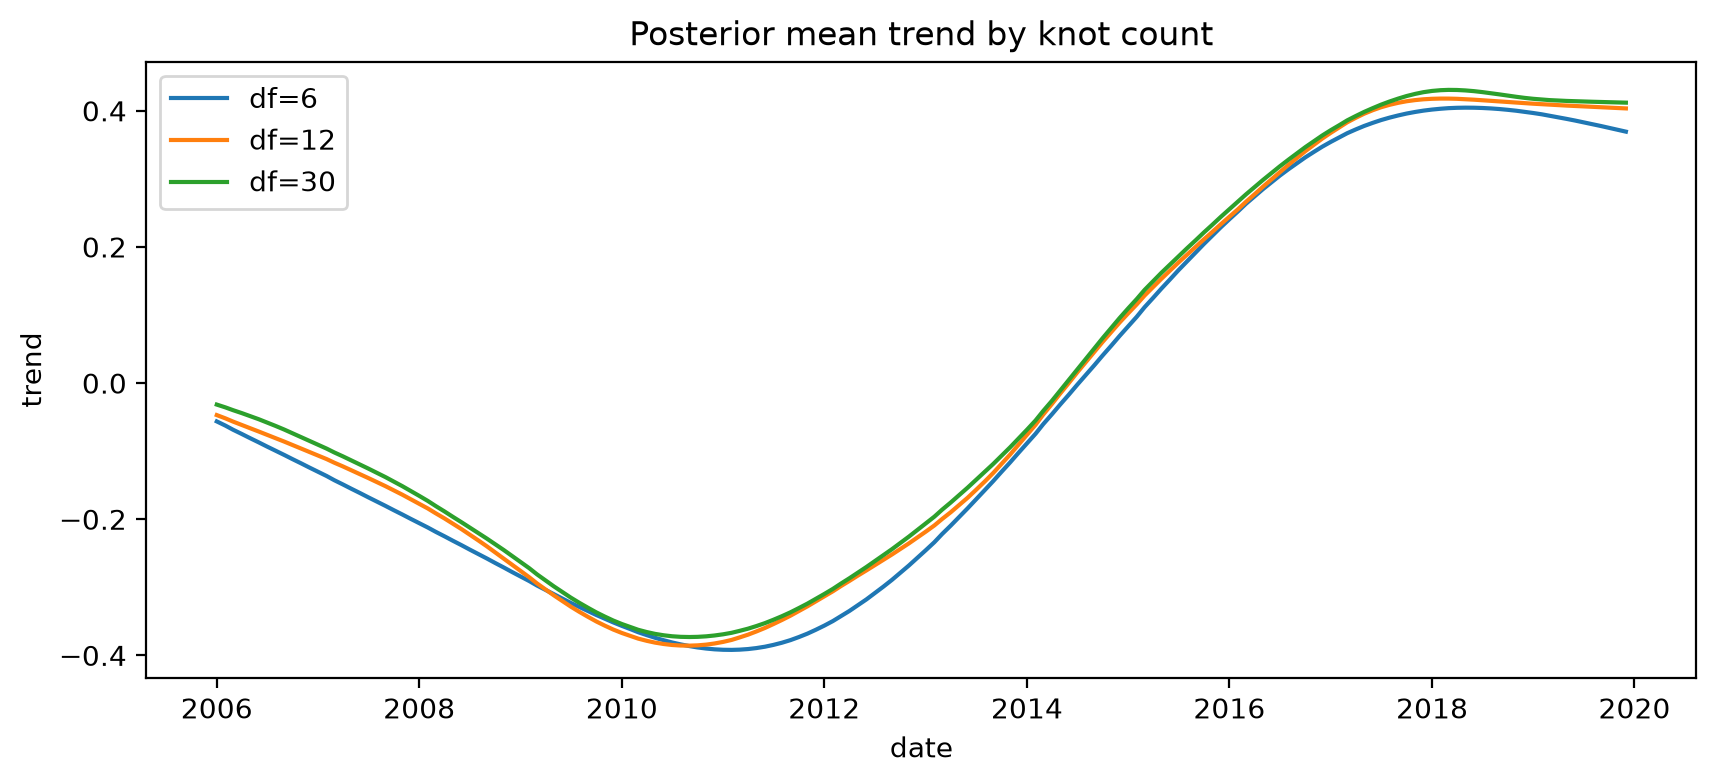

,pre-period R²,sigma_smooth
df,,
6,0.741,0.313
12,0.742,0.273
30,0.742,0.271


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sensitivity = []

for degrees_of_freedom, colour in zip([6, 12, 30], ["C0", "C1", "C2"], strict=True):
    fit = cp.InterruptedTimeSeries(
        df,
        treatment_time,
        formula=(
            f"standardize(deaths) ~ 0 + cr(t, df={degrees_of_freedom}) "
            "+ C(month) + standardize(temp)"
        ),
        model=pspline_model(progressbar=False),
    )
    trend = trend_draws(fit, fit.pre_design).stack(sample=("chain", "draw"))
    ax.plot(
        trend.obs_ind.values,
        trend.mean("sample").values,
        color=colour,
        label=f"df={degrees_of_freedom}",
    )
    sensitivity.append(
        {
            "df": degrees_of_freedom,
            "pre-period R²": fit.score["unit_0_r2"],
            "sigma_smooth": float(fit.model.idata.posterior["sigma_smooth"].mean()),
        }
    )

ax.set(title="Posterior mean trend by knot count", xlabel="date", ylabel="trend")
ax.legend()
plt.show()

pd.DataFrame(sensitivity).set_index("df").round(3)

The three trends sit almost on top of each other, and `sigma_smooth` shrinks as we add knots so that the curve stays about as smooth either way. That's the behavior we want ... `df` is no longer a modeling choice we have to tune. We just set the resolution high enough and forget it.

In [74]:
print(result.effect_summary())

print(result_linear.effect_summary())

EffectSummary(table=                 mean     median  hdi_lower  hdi_upper  p_gt_0  relative_mean  \
average      0.987617   0.964089    0.39757   1.652030  0.9995     372.882744   
cumulative  28.640904  27.958592   11.52952  47.908873  0.9995     372.886016   

            relative_hdi_lower  relative_hdi_upper  
average           -1861.079475         2537.880799  
cumulative        -1861.079257         2537.881246  , text='During the Post-period (2020-01-01 00:00:00 to 2022-05-01 00:00:00), the response variable had an average value of approx. 1.45. By contrast, in the absence of an intervention, we would have expected an average response of 0.46. The 95% interval of this counterfactual prediction is [-0.21, 1.05]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 0.99 with a 95% interval of [0.40, 1.65].\n\nSumming up the individual data points during the Post-period, the resp

Similarly, we can unpack each component of the model to see what its cumulative behavior contributes over the pre-treatment period.

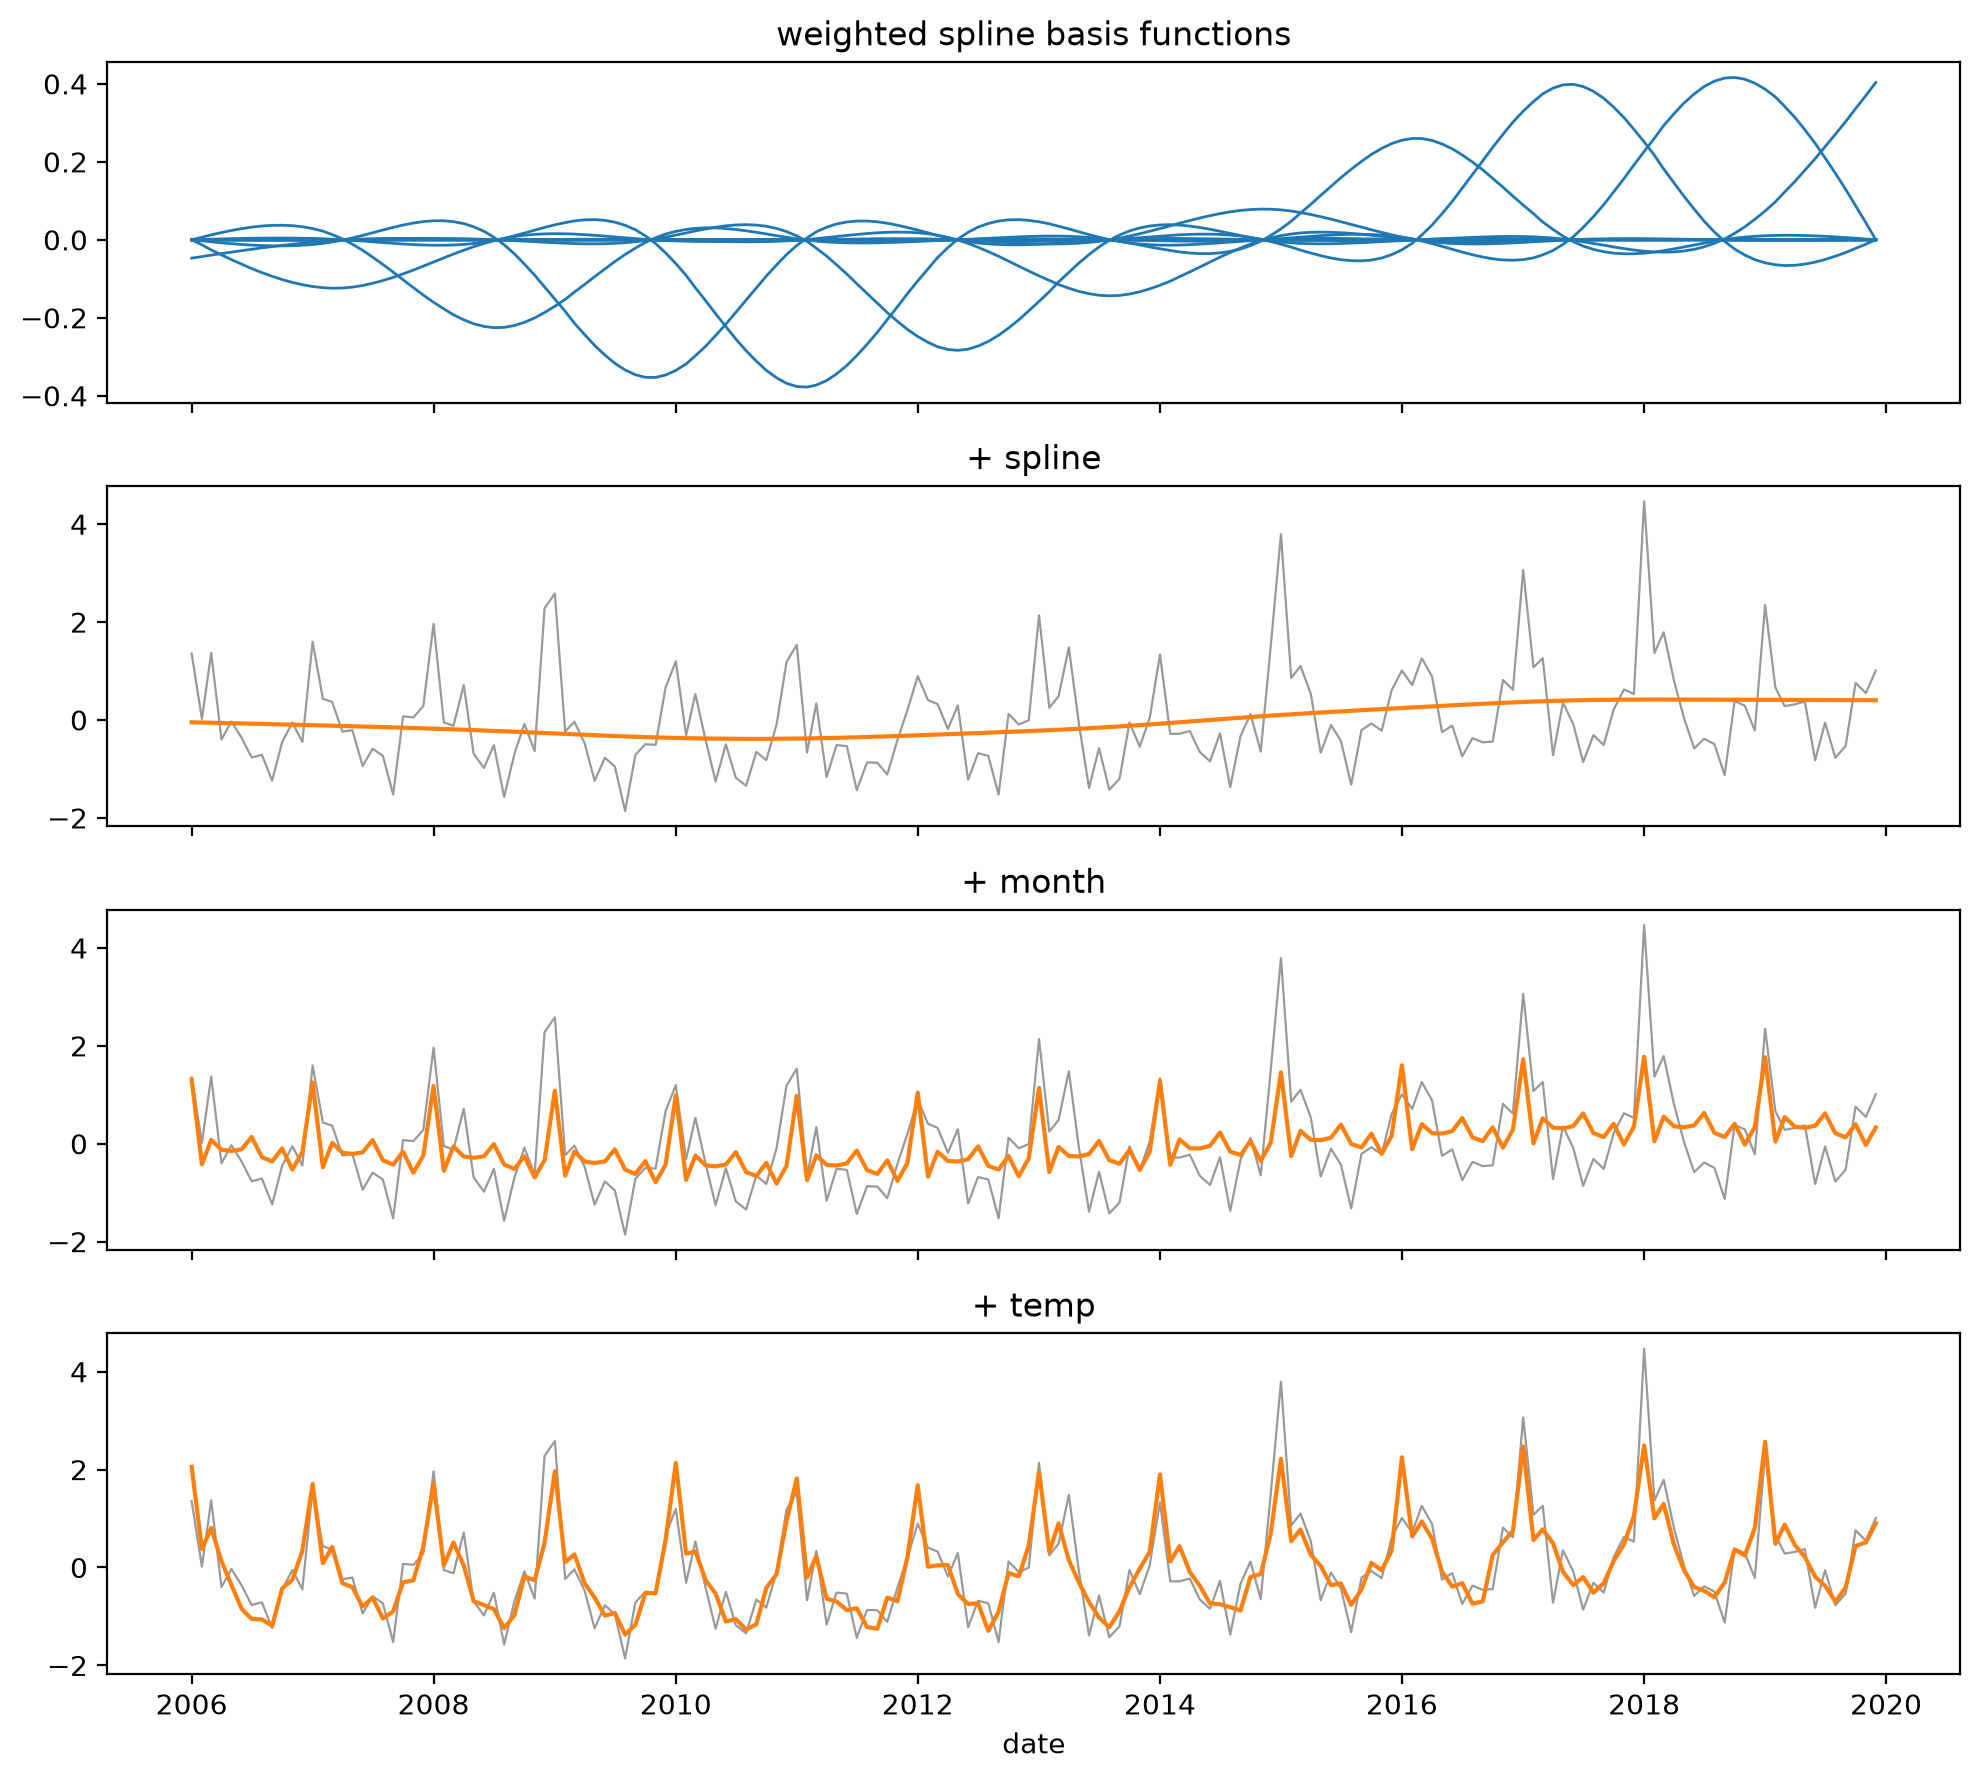

In [20]:
X = result.pre_design["X"]
beta = (
    result.model.idata.posterior["beta"].isel(treated_units=0).mean(("chain", "draw"))
)
dates = X.obs_ind.values

blocks = {
    "spline": [c for c in X.coeffs.values if c.startswith("cr(")],
    "month": [c for c in X.coeffs.values if c.startswith("C(month)")],
    "temp": [c for c in X.coeffs.values if "temp" in c],
}

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

# weighted basis functions from each cr() column * its coefficient.
for col in blocks["spline"]:
    axes[0].plot(dates, X.sel(coeffs=col) * beta.sel(coeffs=col), color="C0", lw=1)
axes[0].set_title("weighted spline basis functions")

# add each block to the fitted mean.
running = 0
for ax, (name, cols) in zip(axes[1:], blocks.items(), strict=True):
    running = running + (X.sel(coeffs=cols) * beta.sel(coeffs=cols)).sum("coeffs")
    ax.plot(
        dates,
        result.pre_design["y"].isel(treated_units=0),
        color="k",
        lw=0.8,
        alpha=0.4,
    )
    ax.plot(dates, running, color="C1")
    ax.set_title(f"+ {name}")

axes[-1].set_xlabel("date")
fig.tight_layout()
plt.show()

## Effect Summary Reporting

For decision-making, you often need a concise summary of the causal effect with key statistics. The `effect_summary()` method provides a decision-ready report with average and cumulative effects, HDI intervals, tail probabilities, and relative effects. This provides a comprehensive summary without manual post-processing.

:::{note}
Note that in this example, the data has been standardized, so the effect estimates are in standardized units. When interpreting the results, keep in mind that the effects are relative to the standardized scale of the outcome variable.
:::


In [21]:
# Generate effect summary for the full post-period
stats = result.effect_summary()
stats.table

,mean,median,hdi_lower,hdi_upper,p_gt_0,relative_mean,relative_hdi_lower,relative_hdi_upper
average,0.987617,0.964089,0.39757,1.652030,0.9995,372.882744,-1861.079475,2537.880799
cumulative,28.640904,27.958592,11.52952,47.908873,0.9995,372.886016,-1861.079257,2537.881246


In [22]:
# View the prose summary
print(stats.text)

During the Post-period (2020-01-01 00:00:00 to 2022-05-01 00:00:00), the response variable had an average value of approx. 1.45. By contrast, in the absence of an intervention, we would have expected an average response of 0.46. The 95% interval of this counterfactual prediction is [-0.21, 1.05]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 0.99 with a 95% interval of [0.40, 1.65].

Summing up the individual data points during the Post-period, the response variable had an overall value of 41.93. By contrast, had the intervention not taken place, we would have expected a sum of 13.29. The 95% interval of this prediction is [-5.98, 30.40].

The 95% HDI of the effect [0.40, 1.65] does not include zero. The posterior probability of an increase is 1.000. Relative to the counterfactual, the effect represents a 372.88% change (95% HDI [-1861.08%, 2537.88%]).

This analysis assumes t

In [23]:
# You can also analyze a specific time window, e.g., the first 6 months of 2020
stats_window = result.effect_summary(
    window=(pd.to_datetime("2020-01-01"), pd.to_datetime("2020-06-30"))
)
stats_window.table

,mean,median,hdi_lower,hdi_upper,p_gt_0,relative_mean,relative_hdi_lower,relative_hdi_upper
average,2.021437,2.010946,1.620051,2.426556,1.0,369.993909,104.723970,750.71222
cumulative,12.128620,12.065678,9.720309,14.559337,1.0,369.993942,104.723971,750.71224


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [24]:
from maketables import ETable

ETable(result, coef_fmt="b:.3f")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x307165550>